In [19]:
# === Cell 1: imports + settings ===
from __future__ import annotations

from pathlib import Path
import pickle
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

# optioneel (pas later nodig)
from scipy import stats
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [20]:
# === Cell 2: load ALL pickles from folder -> single DataFrame ===
from pathlib import Path
import pickle

PICKLE_DIR = Path("/Users/jornvanbeek/Desktop/bluesky/Montecarlo")  # <-- map met pickles
DF_KEY = None  # bv "results_df" als elke pickle een dict is

def load_pickle(path: Path):
    with path.open("rb") as f:
        return pickle.load(f)

dfs = []

pickle_files = sorted(PICKLE_DIR.glob("*.pkl")) + sorted(PICKLE_DIR.glob("*.pickle"))
if not pickle_files:
    raise FileNotFoundError(f"No pickle files found in {PICKLE_DIR}")

for pkl in pickle_files:
    obj = load_pickle(pkl)

    # --- haal DataFrame uit pickle ---
    if isinstance(obj, pd.DataFrame):
        df_i = obj.copy()

    elif isinstance(obj, dict):
        if DF_KEY is not None:
            if DF_KEY not in obj or not isinstance(obj[DF_KEY], pd.DataFrame):
                raise KeyError(f"{pkl.name}: DF_KEY={DF_KEY!r} not found")
            df_i = obj[DF_KEY].copy()
        else:
            for k in ("results_df", "results", "df", "data"):
                if k in obj and isinstance(obj[k], pd.DataFrame):
                    df_i = obj[k].copy()
                    break
            else:
                raise KeyError(f"{pkl.name}: no DataFrame key found")

    else:
        raise TypeError(f"{pkl.name}: unsupported pickle content {type(obj)}")

    # --- voeg configuratie-label toe ---
    # standaard: bestandsnaam zonder extensie
    df_i["config"] = pkl.stem

    dfs.append(df_i)

# combineer alles
df = pd.concat(dfs, ignore_index=True)

print(f"Loaded {len(dfs)} pickles")
print("Combined shape:", df.shape)
print("Configs:", df["config"].unique())
df.head()

Loaded 15 pickles
Combined shape: (850, 84)
Configs: ['SCENARIOTEST_DELAY20' 'SCENARIOTEST_DELAY20CERTAIN'
 'SCENARIOTEST_DELAY20NOPOPUP' 'SCENARIOTEST_DELAY20_highseed'
 'SCENARIOTEST_DELAY20_rate38' 'SCENARIOTEST_DELAY25'
 'SCENARIOTEST_FCFS14' 'SCENARIOTEST_FCFS14_NOPOPUP'
 'SCENARIOTEST_FCFS14_highseed' 'SCENARIOTEST_FCFS20'
 'SCENARIOTEST_FCFS20CERTAIN' 'SCENARIOTEST_FCFS20NOPOPUP'
 'SCENARIOTEST_FCFS20_highseed' 'SCENARIOTEST_FCFS20_rate38'
 'SCENARIOTEST_FCFS25']


,scenario,run,seed,usecache,node,status,maxtime,starttime,endtime,elapsed,mean_pct_extrawork,freezehorizon,popup_planner,error_multiplicator,capacity,pct_count_eq_0,mean_count,mean_count_nonzero,max_count,second_highest_count,max_count_acid,min_count_holding,mean_count_holding,max_count_holding,count_popup,count_fh_margin_at_freeze,min_fh_margin_at_freeze,mean_fh_margin_at_freeze,max_fh_margin_at_freeze,min_EAT_updates,mean_EAT_updates,max_EAT_updates,mean_EAT_updates_nonzero,min_swaps,mean_swaps,max_swaps,mean_swaps_nonzero,amount_of_swaps,min_ttlg_at_freeze,mean_ttlg_at_freeze,median_ttlg_at_freeze,max_ttlg_at_freeze,mean_abs_ttlg_at_freeze,mean_E_TO,mean_abs_E_TO,min_E_TO,max_E_TO,mean_totaldelay,max_totaldelay,mean_totaldelay_nonzero,min_totalspeedup,mean_totalspeedup,mean_totalspeedup_nonzero,min_short_adjacent,mean_short_adjacent,mean_short_adjacent_nonzero,count_short_adjacent_nonzero,min_delay_mach,mean_delay_mach,mean_delay_mach_nonzero,count_delay_mach_nonzero,mean_short_speed,mean_delay_speed,mean_delay_dogleg,mean_short_dogleg,mean_abs_eat_adherence,max_abs_eat_adherence,mean_TP_accuracy,max_abs_TP_accuracy,mean_time_error_at_freeze,max_time_error_at_freeze,min_time_error_at_freeze,mean_abs_time_error_at_freeze,mean_pct_extrawork_popup,mean_pct_extrawork_nonpopup,mean_minwork,mean_totalwork,mean_extrawork,mean_percentile_time,mean_slot_minus_initialslot,mean_abs_slot_minus_initialslot_nonzero,n_acids,error_seed,config
0,SCENARIOTEST_DELAY20,0,0,True,b'S\xfa\xf9\xb3\xcf',done,07:00:00,2026-01-31 23:58:57.645210,2026-02-01 00:07:48.369191,530.723981,-0.555851,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,51.960784,0.892157,1.857143,5.0,3.0,TRA6918SH,NaN,NaN,NaN,6,6,-452.813198,-174.918224,-1.682748,0.0,0.089109,1.0,1.0,0.0,0.015385,2.0,1.5,3.0,-60.0,97.803799,91.862082,415.463199,114.901422,0.020007,0.028034,-0.818743,4.90011,104.702128,434.0,162.230769,-186.0,-4.475177,-78.875,-186.0,-3.723404,-87.5,6,0.0,5.51087,20.28,25,-0.840336,36.021978,25.903846,NaN,50.840196,120.1,0.254902,13.0,-8.408359,155.568253,-249.897358,43.693976,-1.640406,NaN,37535947628.67247,37449261204.841827,-86686423.830638,3.30429,5.885376,93.675265,204,2443250962,SCENARIOTEST_DELAY20
1,SCENARIOTEST_DELAY20,1,1,True,b'S\xfa\xf9\xb3\xc4',done,07:00:00,2026-01-31 23:58:57.695753,2026-02-01 00:08:29.819612,572.123859,-0.661629,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,45.098039,1.044118,1.901786,5.0,4.0,KLM22T,NaN,NaN,NaN,5,5,-491.70309,-233.397299,-62.291508,0.0,1.661765,15.0,6.78,0.0,0.034314,3.0,1.4,7.0,-60.0,105.926521,100.712359,415.108534,127.551824,0.072661,0.072661,0.0,13.489446,125.330769,344.0,161.316832,-174.0,-6.353846,-59.0,-64.0,-7.466667,-56.0,4,0.0,7.833333,22.741935,31,-8.269231,36.880435,29.0,NaN,52.74902,122.2,0.264706,8.0,-13.710093,139.662663,-676.336631,41.649512,-1.228284,NaN,37535947628.67247,37418217293.426056,-117730335.246409,3.30429,2.190316,72.543645,204,2629073562,SCENARIOTEST_DELAY20
2,SCENARIOTEST_DELAY20,2,2,True,b'S\xfa\xf9\xb3\xc9',done,07:00:00,2026-01-31 23:58:57.745343,2026-02-01 00:08:47.031465,589.286122,-0.525402,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,43.627451,1.112745,1.973913,5.0,4.0,TRA6740SH,NaN,NaN,NaN,6,6,-448.839435,-182.155234,-6.976423,0.0,1.367647,25.0,6.2,0.0,0.137255,11.0,4.0,28.0,-60.0,103.076169,105.755505,394.011627,124.282806,0.03891,0.03891,0.0,7.057702,114.797203,404.0,159.378641,-256.0,-10.391608,-78.210526,-232.0,-21.255319,-99.9,10,0.0,7.77,23.545455,33,-5.833333,30.369565,35.647059,NaN,53.585784,121.8,0.563725,12.0,-12.79725,153.299232,-276.978872,43.122435,-1.454445,NaN,37535947628.67247,37465486319.477753,-70461309.194718,3.30429,-0.152588,76.485309,204,1091773355,SCENARIOTEST_DELAY20
3,SCENARIOTEST_DELAY20,3,3,True,b'S\xfa\xf9\xb3\xc6',done,07:00:00,2026-01-31 23:58:57.795084,2026-02-01 00:08:07.202255,549.407171,-0.518293,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,50.980392,0.916667,1.87,5.0,3.0,UAL968SH,NaN,NaN,NaN,7,7,-504.652989,-194.704692,-15.760368,0.0,0.426471,4.0,1.673077,0.0,0.0

In [21]:
# === Cell 3: basic sanity check + harmoniseren kolomnamen ===
# Doel:
# - sample_id: identifier van dezelfde traffic sample over configs heen (repeated measures)
# - condition: de configuratie/conditie label

# 1) Als je andere namen gebruikt, map ze hier:
rename_map = {
    # voorbeelden:
    # "scenario_id": "sample_id",
    # "seed": "sample_id",
    # "config": "condition",
}
if rename_map:
    df = df.rename(columns=rename_map)

# 2) Maak/zet 'condition'
# Als je in Cell 2 'config' hebt toegevoegd (op basis van bestandsnaam),
# dan is dat doorgaans je condition.
if "condition" not in df.columns:
    if "config" in df.columns:
        df["condition"] = df["config"].astype(str)
    else:
        raise ValueError("Missing 'condition' column and no 'config' column found. Add a mapping in rename_map.")
else:
    df["condition"] = df["condition"].astype(str)

# 3) Maak/zet 'sample_id'
# Belangrijk: sample_id moet hetzelfde traffic sample aanduiden over alle conditions heen.
if "sample_id" not in df.columns:
    # probeer een paar veelvoorkomende alternatieven
    for alt in ("title", "scenario", "scenario_id", "seed", "run_id", "mc_id", "sample"):
        if alt in df.columns:
            df["sample_id"] = df[alt].astype(str)
            print(f"sample_id derived from column '{alt}'")
            break
    else:
        # fallback: per condition nummeren.
        # LET OP: repeated-measures klopt alleen als elke condition exact dezelfde
        # volgorde/aantal samples heeft.
        df["sample_id"] = df.groupby("condition").cumcount().astype(str)
        print("WARNING: 'sample_id' missing; created sample_id by per-condition row order (cumcount).")
else:
    df["sample_id"] = df["sample_id"].astype(str)

required = ["sample_id", "condition"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available columns:\n{df.columns.tolist()}")

print("Conditions (n=", df["condition"].nunique(), "):",
      sorted(df["condition"].unique())[:20],
      ("..." if df["condition"].nunique() > 20 else ""))

print("n_samples:", df["sample_id"].nunique(), "rows:", len(df))

# quick peek
(df[required]
 .drop_duplicates()
 .sort_values(required)
 .head(20))

sample_id derived from column 'scenario'
Conditions (n= 15 ): ['SCENARIOTEST_DELAY20', 'SCENARIOTEST_DELAY20CERTAIN', 'SCENARIOTEST_DELAY20NOPOPUP', 'SCENARIOTEST_DELAY20_highseed', 'SCENARIOTEST_DELAY20_rate38', 'SCENARIOTEST_DELAY25', 'SCENARIOTEST_FCFS14', 'SCENARIOTEST_FCFS14_NOPOPUP', 'SCENARIOTEST_FCFS14_highseed', 'SCENARIOTEST_FCFS20', 'SCENARIOTEST_FCFS20CERTAIN', 'SCENARIOTEST_FCFS20NOPOPUP', 'SCENARIOTEST_FCFS20_highseed', 'SCENARIOTEST_FCFS20_rate38', 'SCENARIOTEST_FCFS25'] 
n_samples: 12 rows: 850


,sample_id,condition
0,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20
97,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20_highseed
48,SCENARIOTEST_DELAY20CERTAIN,SCENARIOTEST_DELAY20CERTAIN
49,SCENARIOTEST_DELAY20NOPOPUP,SCENARIOTEST_DELAY20NOPOPUP
241,SCENARIOTEST_DELAY20_rate38,SCENARIOTEST_DELAY20_rate38
289,SCENARIOTEST_DELAY25,SCENARIOTEST_DELAY25
305,SCENARIOTEST_FCFS14,SCENARIOTEST_FCFS14
401,SCENARIOTEST_FCFS14,SCENARIOTEST_FCFS14_highseed
353,SCENARIOTEST_FCFS14_NOPOPUP,SCENARIOTEST_FCFS14_NOPOPUP
545,SCENARIOTEST_FCFS20,SCENARIOTEST_FCFS20


In [22]:
df.head(30)

,scenario,run,seed,usecache,node,status,maxtime,starttime,endtime,elapsed,mean_pct_extrawork,freezehorizon,popup_planner,error_multiplicator,capacity,pct_count_eq_0,mean_count,mean_count_nonzero,max_count,second_highest_count,max_count_acid,min_count_holding,mean_count_holding,max_count_holding,count_popup,count_fh_margin_at_freeze,min_fh_margin_at_freeze,mean_fh_margin_at_freeze,max_fh_margin_at_freeze,min_EAT_updates,mean_EAT_updates,max_EAT_updates,mean_EAT_updates_nonzero,min_swaps,mean_swaps,max_swaps,mean_swaps_nonzero,amount_of_swaps,min_ttlg_at_freeze,mean_ttlg_at_freeze,median_ttlg_at_freeze,max_ttlg_at_freeze,mean_abs_ttlg_at_freeze,mean_E_TO,mean_abs_E_TO,min_E_TO,max_E_TO,mean_totaldelay,max_totaldelay,mean_totaldelay_nonzero,min_totalspeedup,mean_totalspeedup,mean_totalspeedup_nonzero,min_short_adjacent,mean_short_adjacent,mean_short_adjacent_nonzero,count_short_adjacent_nonzero,min_delay_mach,mean_delay_mach,mean_delay_mach_nonzero,count_delay_mach_nonzero,mean_short_speed,mean_delay_speed,mean_delay_dogleg,mean_short_dogleg,mean_abs_eat_adherence,max_abs_eat_adherence,mean_TP_accuracy,max_abs_TP_accuracy,mean_time_error_at_freeze,max_time_error_at_freeze,min_time_error_at_freeze,mean_abs_time_error_at_freeze,mean_pct_extrawork_popup,mean_pct_extrawork_nonpopup,mean_minwork,mean_totalwork,mean_extrawork,mean_percentile_time,mean_slot_minus_initialslot,mean_abs_slot_minus_initialslot_nonzero,n_acids,error_seed,config,condition,sample_id
0,SCENARIOTEST_DELAY20,0,0,True,b'S\xfa\xf9\xb3\xcf',done,07:00:00,2026-01-31 23:58:57.645210,2026-02-01 00:07:48.369191,530.723981,-0.555851,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,51.960784,0.892157,1.857143,5.0,3.0,TRA6918SH,NaN,NaN,NaN,6,6,-452.813198,-174.918224,-1.682748,0.0,0.089109,1.0,1.0,0.0,0.015385,2.0,1.5,3.0,-60.0,97.803799,91.862082,415.463199,114.901422,0.020007,0.028034,-0.818743,4.90011,104.702128,434.0,162.230769,-186.0,-4.475177,-78.875,-186.0,-3.723404,-87.5,6,0.0,5.51087,20.28,25,-0.840336,36.021978,25.903846,NaN,50.840196,120.1,0.254902,13.0,-8.408359,155.568253,-249.897358,43.693976,-1.640406,NaN,37535947628.67247,37449261204.841827,-86686423.830638,3.30429,5.885376,93.675265,204,2443250962,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20
1,SCENARIOTEST_DELAY20,1,1,True,b'S\xfa\xf9\xb3\xc4',done,07:00:00,2026-01-31 23:58:57.695753,2026-02-01 00:08:29.819612,572.123859,-0.661629,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,45.098039,1.044118,1.901786,5.0,4.0,KLM22T,NaN,NaN,NaN,5,5,-491.70309,-233.397299,-62.291508,0.0,1.661765,15.0,6.78,0.0,0.034314,3.0,1.4,7.0,-60.0,105.926521,100.712359,415.108534,127.551824,0.072661,0.072661,0.0,13.489446,125.330769,344.0,161.316832,-174.0,-6.353846,-59.0,-64.0,-7.466667,-56.0,4,0.0,7.833333,22.741935,31,-8.269231,36.880435,29.0,NaN,52.74902,122.2,0.264706,8.0,-13.710093,139.662663,-676.336631,41.649512,-1.228284,NaN,37535947628.67247,37418217293.426056,-117730335.246409,3.30429,2.190316,72.543645,204,2629073562,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20
2,SCENARIOTEST_DELAY20,2,2,True,b'S\xfa\xf9\xb3\xc9',done,07:00:00,2026-01-31 23:58:57.745343,2026-02-01 00:08:47.031465,589.286122,-0.525402,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,43.627451,1.112745,1.973913,5.0,4.0,TRA6740SH,NaN,NaN,NaN,6,6,-448.839435,-182.155234,-6.976423,0.0,1.367647,25.0,6.2,0.0,0.137255,11.0,4.0,28.0,-60.0,103.076169,105.755505,394.011627,124.282806,0.03891,0.03891,0.0,7.057702,114.797203,404.0,159.378641,-256.0,-10.391608,-78.210526,-232.0,-21.255319,-99.9,10,0.0,7.77,23.545455,33,-5.833333,30.369565,35.647059,NaN,53.585784,121.8,0.563725,12.0,-12.79725,153.299232,-276.978872,43.122435,-1.454445,NaN,37535947628.67247,37465486319.477753,-70461309.194718,3.30429,-0.152588,76.485309,204,1091773355,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20
3,SCENARIOTEST_DELAY20,3,3,True,b'S\xfa\xf9\xb3\xc6',done,07:00:00,2026-01-31 23:58:57.795084,2026-02-01 00:08:07.202255,549.407171,-0.518293,1200.0,DELAY,"[1.0, 

In [33]:
# === Cell 4: kies metrics + numeric coercion + clean subset ===
MEASURES = [
    # <-- vul met jouw kolommen
    'mean_pct_extrawork','pct_count_eq_0', 'mean_count', 'mean_EAT_updates', 'mean_swaps', 'amount_of_swaps', 'mean_totaldelay', 'mean_totalspeedup' 
]

present = [m for m in MEASURES if m in df.columns]
missing_m = [m for m in MEASURES if m not in df.columns]
if missing_m:
    print("WARNING: missing measures (skipped):", missing_m)
MEASURES = present
if not MEASURES:
    raise ValueError("No measures found. Set MEASURES to existing numeric columns.")

df_num = df.copy()
for m in MEASURES:
    df_num[m] = pd.to_numeric(df_num[m], errors="coerce")

df_clean = df_num.dropna(subset=["sample_id", "condition"] + MEASURES).copy()

print("Rows:", len(df), "->", len(df_clean), "after dropping NA in required/measures")
df_clean.head()

Rows: 850 -> 741 after dropping NA in required/measures


,scenario,run,seed,usecache,node,status,maxtime,starttime,endtime,elapsed,mean_pct_extrawork,freezehorizon,popup_planner,error_multiplicator,capacity,pct_count_eq_0,mean_count,mean_count_nonzero,max_count,second_highest_count,max_count_acid,min_count_holding,mean_count_holding,max_count_holding,count_popup,count_fh_margin_at_freeze,min_fh_margin_at_freeze,mean_fh_margin_at_freeze,max_fh_margin_at_freeze,min_EAT_updates,mean_EAT_updates,max_EAT_updates,mean_EAT_updates_nonzero,min_swaps,mean_swaps,max_swaps,mean_swaps_nonzero,amount_of_swaps,min_ttlg_at_freeze,mean_ttlg_at_freeze,median_ttlg_at_freeze,max_ttlg_at_freeze,mean_abs_ttlg_at_freeze,mean_E_TO,mean_abs_E_TO,min_E_TO,max_E_TO,mean_totaldelay,max_totaldelay,mean_totaldelay_nonzero,min_totalspeedup,mean_totalspeedup,mean_totalspeedup_nonzero,min_short_adjacent,mean_short_adjacent,mean_short_adjacent_nonzero,count_short_adjacent_nonzero,min_delay_mach,mean_delay_mach,mean_delay_mach_nonzero,count_delay_mach_nonzero,mean_short_speed,mean_delay_speed,mean_delay_dogleg,mean_short_dogleg,mean_abs_eat_adherence,max_abs_eat_adherence,mean_TP_accuracy,max_abs_TP_accuracy,mean_time_error_at_freeze,max_time_error_at_freeze,min_time_error_at_freeze,mean_abs_time_error_at_freeze,mean_pct_extrawork_popup,mean_pct_extrawork_nonpopup,mean_minwork,mean_totalwork,mean_extrawork,mean_percentile_time,mean_slot_minus_initialslot,mean_abs_slot_minus_initialslot_nonzero,n_acids,error_seed,config,condition,sample_id
0,SCENARIOTEST_DELAY20,0,0,True,b'S\xfa\xf9\xb3\xcf',done,07:00:00,2026-01-31 23:58:57.645210,2026-02-01 00:07:48.369191,530.723981,-0.555851,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,51.960784,0.892157,1.857143,5.0,3.0,TRA6918SH,NaN,NaN,NaN,6,6,-452.813198,-174.918224,-1.682748,0.0,0.089109,1.0,1.0,0.0,0.015385,2.0,1.5,3.0,-60.0,97.803799,91.862082,415.463199,114.901422,0.020007,0.028034,-0.818743,4.90011,104.702128,434.0,162.230769,-186.0,-4.475177,-78.875,-186.0,-3.723404,-87.5,6,0.0,5.51087,20.28,25,-0.840336,36.021978,25.903846,NaN,50.840196,120.1,0.254902,13.0,-8.408359,155.568253,-249.897358,43.693976,-1.640406,NaN,37535947628.67247,37449261204.841827,-86686423.830638,3.30429,5.885376,93.675265,204,2443250962,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20
1,SCENARIOTEST_DELAY20,1,1,True,b'S\xfa\xf9\xb3\xc4',done,07:00:00,2026-01-31 23:58:57.695753,2026-02-01 00:08:29.819612,572.123859,-0.661629,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,45.098039,1.044118,1.901786,5.0,4.0,KLM22T,NaN,NaN,NaN,5,5,-491.70309,-233.397299,-62.291508,0.0,1.661765,15.0,6.78,0.0,0.034314,3.0,1.4,7.0,-60.0,105.926521,100.712359,415.108534,127.551824,0.072661,0.072661,0.0,13.489446,125.330769,344.0,161.316832,-174.0,-6.353846,-59.0,-64.0,-7.466667,-56.0,4,0.0,7.833333,22.741935,31,-8.269231,36.880435,29.0,NaN,52.74902,122.2,0.264706,8.0,-13.710093,139.662663,-676.336631,41.649512,-1.228284,NaN,37535947628.67247,37418217293.426056,-117730335.246409,3.30429,2.190316,72.543645,204,2629073562,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20
2,SCENARIOTEST_DELAY20,2,2,True,b'S\xfa\xf9\xb3\xc9',done,07:00:00,2026-01-31 23:58:57.745343,2026-02-01 00:08:47.031465,589.286122,-0.525402,1200.0,DELAY,"[1.0, 1.0, 1.0, 1.0]",36.0,43.627451,1.112745,1.973913,5.0,4.0,TRA6740SH,NaN,NaN,NaN,6,6,-448.839435,-182.155234,-6.976423,0.0,1.367647,25.0,6.2,0.0,0.137255,11.0,4.0,28.0,-60.0,103.076169,105.755505,394.011627,124.282806,0.03891,0.03891,0.0,7.057702,114.797203,404.0,159.378641,-256.0,-10.391608,-78.210526,-232.0,-21.255319,-99.9,10,0.0,7.77,23.545455,33,-5.833333,30.369565,35.647059,NaN,53.585784,121.8,0.563725,12.0,-12.79725,153.299232,-276.978872,43.122435,-1.454445,NaN,37535947628.67247,37465486319.477753,-70461309.194718,3.30429,-0.152588,76.485309,204,1091773355,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20
3,SCENARIOTEST_DELAY20,3,3,True,b'S\xfa\xf9\xb3\xc6',done,07:00:00,2026-01-31 23:58:57.795084,2026-02-01 00:08:07.202255,549.407171,-0.518293,1200.0,DELAY,"[1.0, 

In [34]:
# === Cell: Z-scores per sample (Vanwelsenaere-style) ===
# Assumes df_clean contains: sample_id, condition, + MEASURES (numeric)

def add_zscores_within_sample(df_long: pd.DataFrame, measures: list[str], sample_col: str = "sample_id") -> pd.DataFrame:
    out = df_long.copy()
    for m in measures:
        mu = out.groupby(sample_col)[m].transform("mean")
        sd = out.groupby(sample_col)[m].transform(lambda x: x.std(ddof=0))
        out[m + "_z"] = (out[m] - mu) / sd.replace(0, np.nan)
    return out

df_z = add_zscores_within_sample(df_clean, MEASURES)
ZCOLS = [m + "_z" for m in MEASURES]

# quick check
df_z[["sample_id", "condition"] + ZCOLS].head()

,sample_id,condition,mean_pct_extrawork_z,pct_count_eq_0_z,mean_count_z,mean_EAT_updates_z,mean_swaps_z,amount_of_swaps_z,mean_totaldelay_z,mean_totalspeedup_z
0,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,0.064184,1.699555,-1.114223,-0.909207,-1.027781,-0.945146,-1.192658,1.502397
1,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,-0.804194,0.306058,-0.364031,2.351886,-0.433648,-0.303030,0.039969,0.775486
2,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,0.314149,0.007452,-0.025235,1.741997,2.797395,3.068075,-0.589445,-0.786840
3,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,0.372510,1.500484,-0.993225,-0.209647,-0.554704,-0.463559,-1.002578,0.932169
4,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20,1.026166,1.301413,-0.364031,0.583208,1.874240,2.104902,-0.152890,0.332006


/var/folders/0v/cqt77j_s3c30c4jmmxgy9_m40000gn/T/ipykernel_5600/562325526.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)


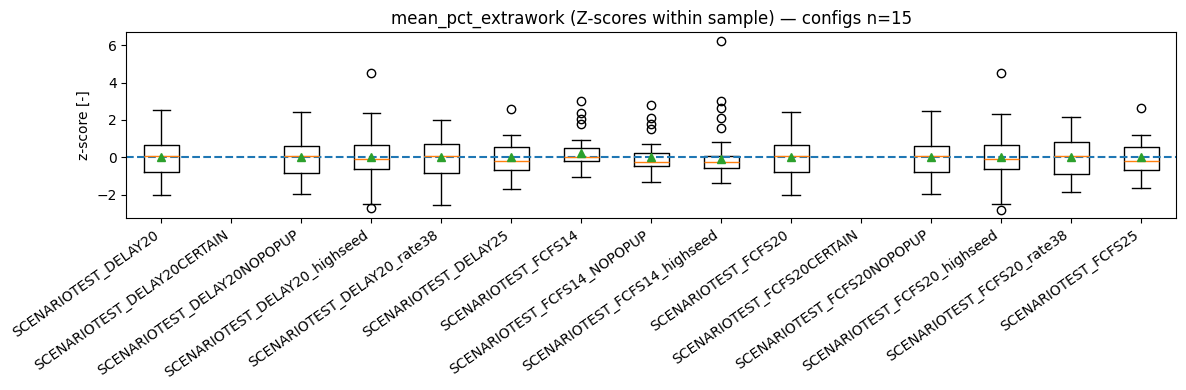

/var/folders/0v/cqt77j_s3c30c4jmmxgy9_m40000gn/T/ipykernel_5600/562325526.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)


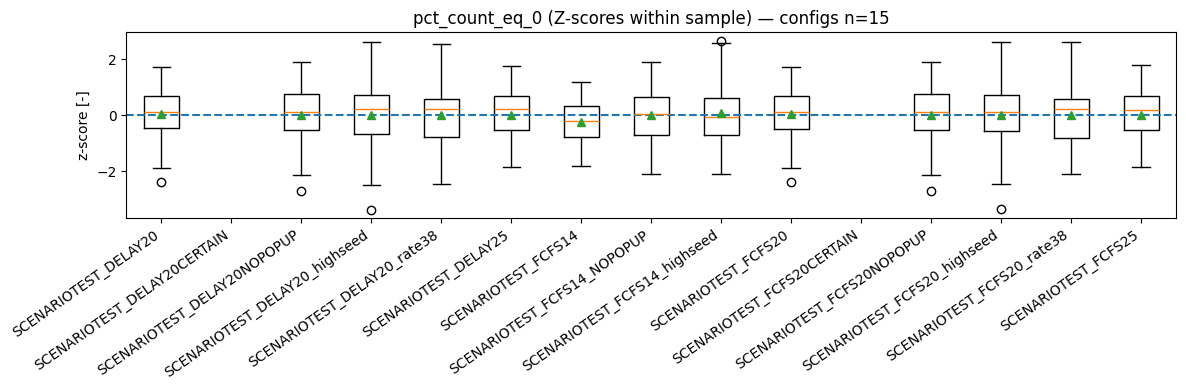

/var/folders/0v/cqt77j_s3c30c4jmmxgy9_m40000gn/T/ipykernel_5600/562325526.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)


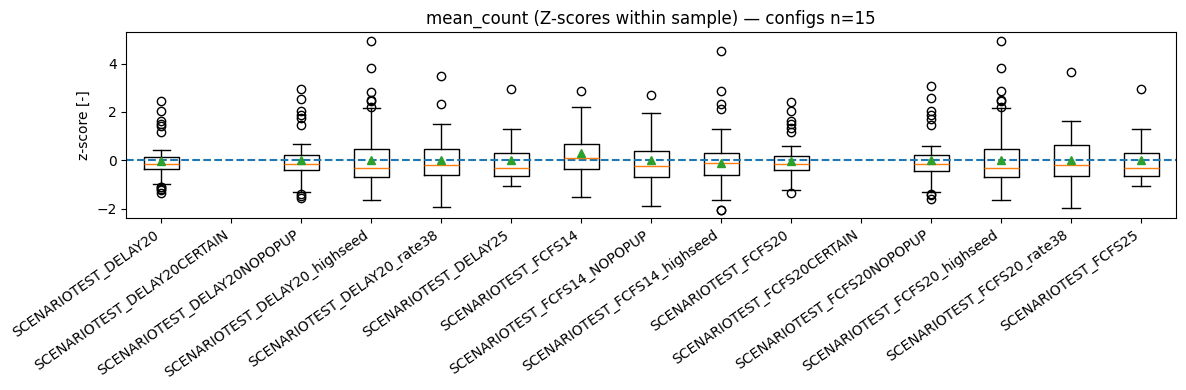

/var/folders/0v/cqt77j_s3c30c4jmmxgy9_m40000gn/T/ipykernel_5600/562325526.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)


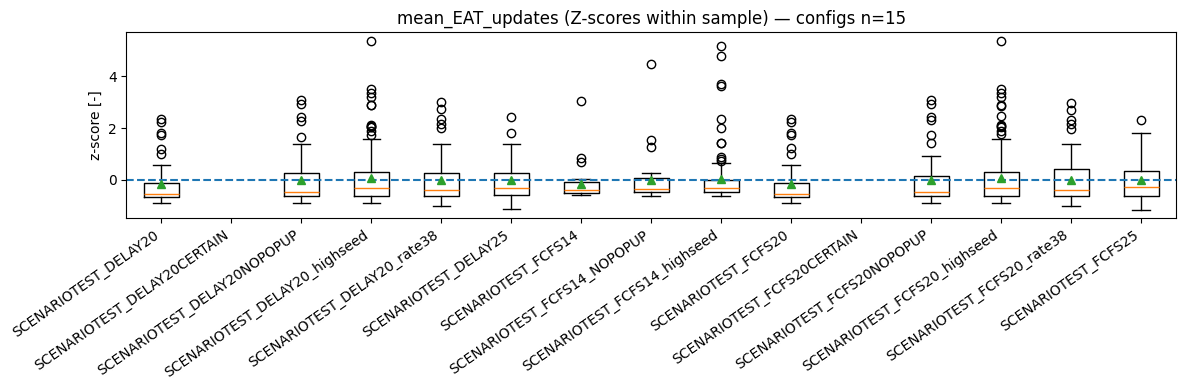

/var/folders/0v/cqt77j_s3c30c4jmmxgy9_m40000gn/T/ipykernel_5600/562325526.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)


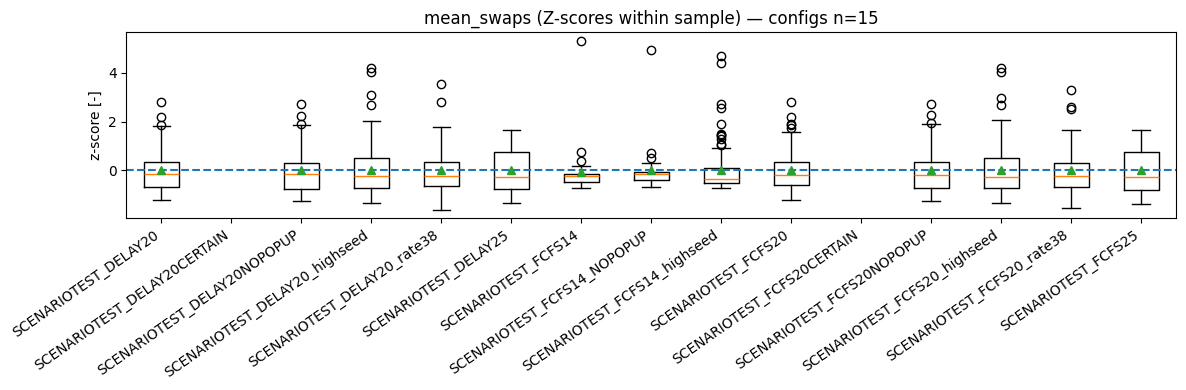

/var/folders/0v/cqt77j_s3c30c4jmmxgy9_m40000gn/T/ipykernel_5600/562325526.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)


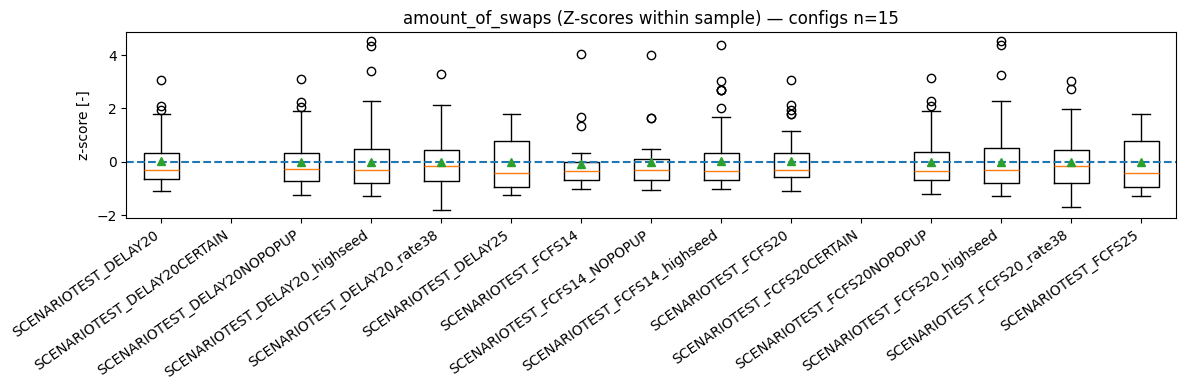

/var/folders/0v/cqt77j_s3c30c4jmmxgy9_m40000gn/T/ipykernel_5600/562325526.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)


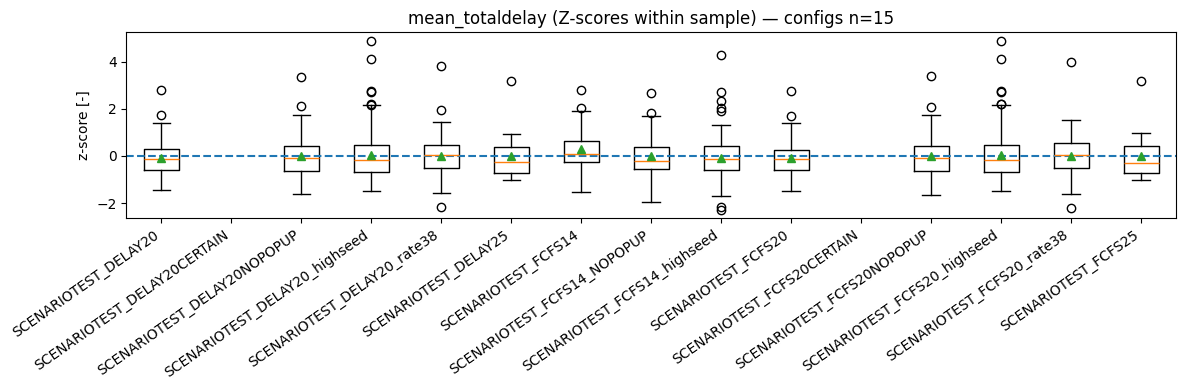

/var/folders/0v/cqt77j_s3c30c4jmmxgy9_m40000gn/T/ipykernel_5600/562325526.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)


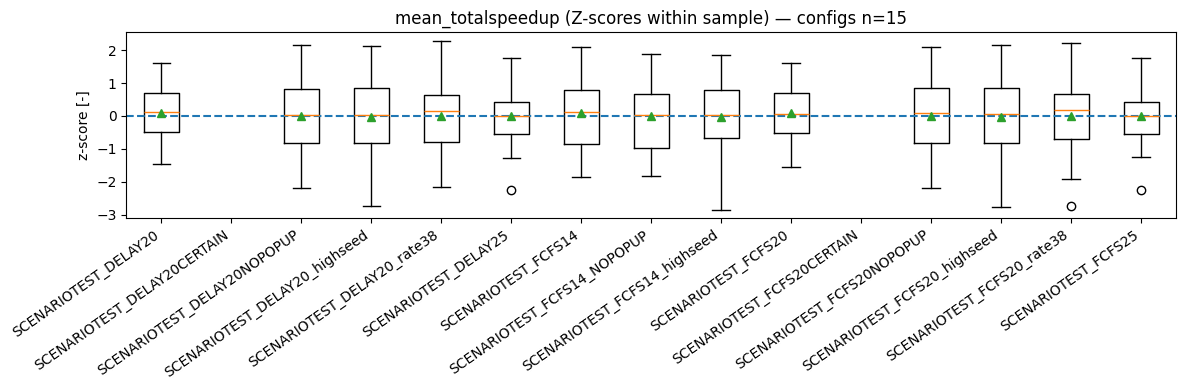

In [35]:
# === Cell 5: Boxplots (per measure) met selectie van configuraties ===
# Vereist: df_z bestaat en bevat kolommen: "condition", en per measure: f"{measure}_z"
# Vereist: MEASURES bestaat (list van measures)

# --- Selecties ---
SELECTED_MEASURES = MEASURES              # of bv ["LLDA", "extrawork"]
SELECTED_CONFIGS  = None                 # None = alle configs, of bv ["SCENARIOTEST_FCFS20", "SCENARIOTEST_DELAY20"]
ORDER_CONFIGS     = None                 # None = automatisch sorteren, of zelfde lijst als SELECTED_CONFIGS voor vaste volgorde

SHOW_MEANS = True
FIGSIZE = (12, 4)

def boxplots_zscores_configs(
    df_long: pd.DataFrame,
    measures: list[str],
    configs: list[str] | None = None,
    order: list[str] | None = None,
    cond_col: str = "condition",
):
    # filter configs
    d0 = df_long.copy()
    if configs is not None:
        d0 = d0[d0[cond_col].isin(configs)].copy()

    if order is None:
        conds = sorted(d0[cond_col].dropna().unique())
    else:
        conds = [c for c in order if c in set(d0[cond_col].dropna().unique())]

    if not conds:
        raise ValueError("No conditions left after filtering. Check SELECTED_CONFIGS / ORDER_CONFIGS.")

    for m in measures:
        zc = m + "_z"
        if zc not in d0.columns:
            print(f"SKIP {m}: missing column {zc}")
            continue

        d = d0[[cond_col, zc]].dropna().copy()
        groups = [d.loc[d[cond_col] == c, zc].to_numpy() for c in conds]

        plt.figure(figsize=FIGSIZE)
        plt.boxplot(groups, labels=conds, showmeans=SHOW_MEANS)
        plt.axhline(0.0, linestyle="--")
        plt.title(f"{m} (Z-scores within sample) — configs n={len(conds)}")
        plt.ylabel("z-score [-]")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()

boxplots_zscores_configs(
    df_z,
    measures=SELECTED_MEASURES,
    configs=SELECTED_CONFIGS,
    order=ORDER_CONFIGS,
)

In [43]:
# === Cell (optional): Combined long-format table for reporting ===
# Median/mean of z-scores per condition, per measure
z_summary = (
    df_z.groupby("condition")[ZCOLS]
      .agg(["mean", "median", "std", "count"])
      .sort_index()
)
z_summary

mean_pct_extrawork_z                           pct_count_eq_0_z                            mean_count_z                      \
                                              mean    median       std count             mean    median       std count          mean    median       std   
condition                                                                                                                                                   
SCENARIOTEST_DELAY20                  3.463496e-03  0.078796  1.016619    46     2.043474e-02  0.106987  0.898300    46 -3.891314e-02 -0.146234  0.831737   
SCENARIOTEST_DELAY20CERTAIN                    NaN       NaN       NaN     0              NaN       NaN       NaN     0           NaN       NaN       NaN   
SCENARIOTEST_DELAY20NOPOPUP           2.847963e-16  0.070168  1.011050    46     7.626749e-16  0.094868  1.011050    46  9.798925e-16 -0.127511  1.011050   
SCENARIOTEST_DELAY20_highseed        -1.129935e-03 -0.079502  1.001752   141    -6.666653e-03  0.206523  1.037380   141  1.269507e-02 -0.315632  1.054843   
SCENARIOTEST_DELAY20_rate38          -2.692881e-16  0.095962  1.010811    47     7.653452e-16  0.207789  1.010811    47 -2.244068e-16 -0.209545  1.010811   
SCENARIOTEST_DELAY25                 -1.110223e-16 -0.194177  1.032796    16    -5.993470e-16  0.201704  1.032796    16 -3.608225e-16 -0.299869  1.032796   
SCENARIOTEST_FCFS14                   2.562439e-01  0.000716  1.007259    28    -2.387001e-01 -0.214401  0.762396    28  3.003226e-01  0.082484  0.972588   
SCENARIOTEST_FCFS14_NOPOPUP          -1.348128e-16 -0.257156  1.018350    28     1.201420e-15  0.027799  1.018350    28  6.185528e-16 -0.215061  1.018350   
SCENARIOTEST_FCFS14_highseed         -7.884428e-02 -0.228852  0.995559    91     7.344618e-02 -0.068608  1.060503    91 -9.240696e-02 -0.109536  1.000875   
SCENARIOTEST_FCFS20                  -2.238379e-03  0.074212  1.009680    46     2.252847e-02  0.108945  0.904689    46 -3.867747e-02 -0.147163  0.828769   
SCENARIOTEST_FCFS20CERTAIN                     NaN       NaN       NaN     0              NaN       NaN       NaN     0           NaN       NaN       NaN   
SCENARIOTEST_FCFS20NOPOPUP            2.292852e-16  0.078200  1.011050    46     2.413528e-16  0.097416  1.011050    46  3.185857e-16 -0.129063  1.011050   
SCENARIOTEST_FCFS20_highseed          7.302514e-04 -0.068245  1.004007   141    -7.349714e-03  0.108945  1.035575   141  1.261818e-02 -0.292511  1.055598   
SCENARIOTEST_FCFS20_rate38            5.492061e-17  0.060276  1.010811    47    -4.086566e-16  0.203242  1.010811    47 -6.259768e-16 -0.200165  1.010811   
SCENARIOTEST_FCFS25                  -2.324529e-16 -0.196220  1.032796    16    -2.975051e-16  0.165650  1.032796    16  8.673617e-17 -0.294669  1.032796   

                                    mean_EAT_updates_z                            mean_swaps_z                           amount_of_swaps_z            \
                              count               mean    median       std count          mean    median       std count              mean    median   
condition                                                                                                                                              
SCENARIOTEST_DELAY20             46      -1.703785e-01 -0.545086  0.825633    46  1.975141e-02 -0.167782  0.987589    46      1.802730e-02 -0.303030   
SCENARIOTEST_DELAY20CERTAIN       0                NaN       NaN       NaN     0           NaN       NaN       NaN     0               NaN       NaN   
SCENARIOTEST_DELAY20NOPOPUP      46       8.085320e-17 -0.471354  1.011050    46  1.122291e-16 -0.162433  1.011050    46      4.102998e-17 -0.271150   
SCENARIOTEST_DELAY20_highseed   141       5.558449e-02 -0.301130  1.050693   141 -6.443724e-03 -0.248862  1.010962   141     -5.881246e-03 -0.303030   
SCENARIOTEST_DELAY20_rate38      47       6.614095e-17 -0.412543  1.010811    47  8.503836e-17 -0.227538  1.010811    47      2.125959e-17 

In [44]:
# === Cell: Helper long -> wide (required for Friedman/Wilcoxon) ===
# Assumes df_z exists and has columns: sample_id, condition, <measure>_z

def to_wide(df_long: pd.DataFrame, value_col: str,
            sample_col: str = "sample_id",
            cond_col: str = "condition") -> pd.DataFrame:
    wide = df_long.pivot_table(index=sample_col, columns=cond_col, values=value_col, aggfunc="mean")
    # complete-case only (Friedman requires paired observations across all included conditions)
    return wide.dropna(axis=0, how="any")

In [47]:
m = MEASURES[0]
zc = m + "_z"

wide_raw = df_z.pivot_table(index="sample_id", columns="condition", values=zc, aggfunc="mean")

print("RAW wide shape:", wide_raw.shape)                 # verwacht (12, 15)
print("NaNs per condition:\n", wide_raw.isna().sum().sort_values(ascending=False).head(20))
print("NaNs per sample (rows):\n", wide_raw.isna().sum(axis=1).sort_values(ascending=False).head(20))

wide_cc = wide_raw.dropna(axis=0, how="any")
print("COMPLETE-CASE wide shape:", wide_cc.shape)        # dit bepaalt je Friedman n
wide_cc.head()

RAW wide shape: (10, 13)
NaNs per condition:
 condition
SCENARIOTEST_DELAY20             9
SCENARIOTEST_DELAY20NOPOPUP      9
SCENARIOTEST_DELAY20_highseed    9
SCENARIOTEST_DELAY20_rate38      9
SCENARIOTEST_DELAY25             9
SCENARIOTEST_FCFS14              9
SCENARIOTEST_FCFS14_NOPOPUP      9
SCENARIOTEST_FCFS14_highseed     9
SCENARIOTEST_FCFS20              9
SCENARIOTEST_FCFS20NOPOPUP       9
SCENARIOTEST_FCFS20_highseed     9
SCENARIOTEST_FCFS20_rate38       9
SCENARIOTEST_FCFS25              9
dtype: int64
NaNs per sample (rows):
 sample_id
SCENARIOTEST_DELAY20NOPOPUP    12
SCENARIOTEST_DELAY20_rate38    12
SCENARIOTEST_DELAY25           12
SCENARIOTEST_FCFS14_NOPOPUP    12
SCENARIOTEST_FCFS20NOPOPUP     12
SCENARIOTEST_FCFS20_rate38     12
SCENARIOTEST_FCFS25            12
SCENARIOTEST_DELAY20           11
SCENARIOTEST_FCFS14            11
SCENARIOTEST_FCFS20            11
dtype: int64
COMPLETE-CASE wide shape: (0, 13)


condition,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20NOPOPUP,SCENARIOTEST_DELAY20_highseed,SCENARIOTEST_DELAY20_rate38,SCENARIOTEST_DELAY25,SCENARIOTEST_FCFS14,SCENARIOTEST_FCFS14_NOPOPUP,SCENARIOTEST_FCFS14_highseed,SCENARIOTEST_FCFS20,SCENARIOTEST_FCFS20NOPOPUP,SCENARIOTEST_FCFS20_highseed,SCENARIOTEST_FCFS20_rate38,SCENARIOTEST_FCFS25
sample_id,,,,,,,,,,,,,


In [53]:
# === Cell: Friedman ANOVA (SciPy friedmanchisquare) + Kendall's W ===
# Fixes included:
# 1) Enforce correct pairing by optionally recomputing sample_id from a chosen column (e.g. "run" or "seed")
# 2) Avoid the "wide becomes empty" problem by restricting to common samples across conditions
# 3) Optionally restrict to conditions that are complete (no NaNs) for this measure
# 4) Better diagnostics when it still skips

def _ensure_sample_id(df_long: pd.DataFrame, sample_col: str | None) -> pd.DataFrame:
    """
    If sample_col is provided, set df_long['sample_id'] = df_long[sample_col].
    Use this if your current sample_id is wrong (e.g., derived from 'scenario' which is actually config-like).
    """
    if sample_col is None:
        return df_long

    if sample_col not in df_long.columns:
        raise ValueError(f"sample_col={sample_col!r} not in df.columns. Available: {df_long.columns.tolist()}")

    out = df_long.copy()
    out["sample_id"] = out[sample_col].astype(str)
    return out


def _filter_common_samples(df_long: pd.DataFrame, cond_col: str = "condition") -> pd.DataFrame:
    """Keep only sample_ids that appear in *all* conditions (repeated-measures safe)."""
    sets = df_long.groupby(cond_col)["sample_id"].apply(lambda s: set(s.astype(str)))
    common = set.intersection(*sets.values) if len(sets) else set()
    return df_long[df_long["sample_id"].isin(common)].copy()


def friedman_test_for_measure(
    df_long: pd.DataFrame,
    measure: str,
    order: list[str] | None = None,
    *,
    sample_col: str | None = None,        # <-- set to "run" or "seed" if needed
    enforce_common_samples: bool = True,  # <-- recommended True
    drop_incomplete_conditions: bool = True,  # <-- recommended True
    cond_col: str = "condition",
) -> dict:
    zc = measure + "_z"

    if zc not in df_long.columns:
        return {
            "measure": measure,
            "chi2": np.nan,
            "p": np.nan,
            "n_samples": 0,
            "k_conditions": 0,
            "kendall_W": np.nan,
            "conditions": [],
            "note": f"missing column {zc}",
        }

    # Optionally rebuild sample_id from a known-good column (e.g., 'run' or 'seed')
    d = _ensure_sample_id(df_long, sample_col=sample_col)

    # Optional: enforce pairing across conditions
    if enforce_common_samples:
        d = _filter_common_samples(d, cond_col=cond_col)

    # Build wide
    wide = d.pivot_table(index="sample_id", columns=cond_col, values=zc, aggfunc="mean")

    # Order subset (optional)
    if order is not None:
        cols = [c for c in order if c in wide.columns]
        wide = wide[cols]

    # Optionally drop conditions that still have NaNs (so we keep paired rows)
    if drop_incomplete_conditions:
        wide = wide.loc[:, wide.notna().all(axis=0)]

    # Now drop any remaining rows with NaNs (should be none if steps above worked)
    wide = wide.dropna(axis=0, how="any")

    # Diagnostics
    n, k = wide.shape[0], wide.shape[1]
    if k < 3 or n < 3:
        return {
            "measure": measure,
            "chi2": np.nan,
            "p": np.nan,
            "n_samples": int(n),
            "k_conditions": int(k),
            "kendall_W": np.nan,
            "conditions": list(wide.columns),
            "note": (
                f"SKIP: n_samples={n}, k_conditions={k}. "
                f"(try sample_col='run' or 'seed' if pairing is wrong)"
            ),
        }

    arrays = [wide[c].to_numpy() for c in wide.columns]
    chi2, p = stats.friedmanchisquare(*arrays)

    kendall_W = float(chi2) / (n * (k - 1))

    return {
        "measure": measure,
        "chi2": float(chi2),
        "p": float(p),
        "n_samples": int(n),
        "k_conditions": int(k),
        "kendall_W": float(kendall_W),
        "conditions": list(wide.columns),
        "note": "",
    }


def friedman_all_measures(
    df_long: pd.DataFrame,
    measures: list[str],
    order: list[str] | None = None,
    *,
    sample_col: str | None = None,        # <-- set to "run" or "seed"
    enforce_common_samples: bool = True,
    drop_incomplete_conditions: bool = True,
    cond_col: str = "condition",
) -> pd.DataFrame:
    rows = [
        friedman_test_for_measure(
            df_long, m, order=order,
            sample_col=sample_col,
            enforce_common_samples=enforce_common_samples,
            drop_incomplete_conditions=drop_incomplete_conditions,
            cond_col=cond_col,
        )
        for m in measures
    ]
    out = pd.DataFrame(rows).sort_values("p", na_position="last")
    return out


# --- Use it ---
# In jouw df zie ik kolommen: 'run' en 'seed'. Meestal is 'run' de juiste repeated-measures id.
# Probeer eerst 'run'. Als dat niet klopt, probeer 'seed'.
ORDER = None

friedman_results = friedman_all_measures(
    df_z,
    MEASURES,
    order=ORDER,
    sample_col="run",                 # <-- belangrijkste fix t.o.v. je huidige situatie
    enforce_common_samples=True,
    drop_incomplete_conditions=True,
)
friedman_results

,measure,chi2,p,n_samples,k_conditions,kendall_W,conditions,note
0,mean_pct_extrawork,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample..."
1,pct_count_eq_0,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample..."
2,mean_count,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample..."
3,mean_EAT_updates,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample..."
4,mean_swaps,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample..."
5,amount_of_swaps,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample..."
6,mean_totaldelay,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample..."
7,mean_totalspeedup,NaN,NaN,0,0,NaN,[],"SKIP: n_samples=0, k_conditions=0. (try sample..."


In [52]:
wide_raw

condition,SCENARIOTEST_DELAY20,SCENARIOTEST_DELAY20NOPOPUP,SCENARIOTEST_DELAY20_highseed,SCENARIOTEST_DELAY20_rate38,SCENARIOTEST_DELAY25,SCENARIOTEST_FCFS14,SCENARIOTEST_FCFS14_NOPOPUP,SCENARIOTEST_FCFS14_highseed,SCENARIOTEST_FCFS20,SCENARIOTEST_FCFS20NOPOPUP,SCENARIOTEST_FCFS20_highseed,SCENARIOTEST_FCFS20_rate38,SCENARIOTEST_FCFS25
sample_id,,,,,,,,,,,,,
SCENARIOTEST_DELAY20,0.003463,NaN,-0.00113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCENARIOTEST_DELAY20NOPOPUP,NaN,2.847963e-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCENARIOTEST_DELAY20_rate38,NaN,NaN,NaN,-2.692881e-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCENARIOTEST_DELAY25,NaN,NaN,NaN,NaN,-1.110223e-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCENARIOTEST_FCFS14,NaN,NaN,NaN,NaN,NaN,0.256244,NaN,-0.078844,NaN,NaN,NaN,NaN,NaN
SCENARIOTEST_FCFS14_NOPOPUP,NaN,NaN,NaN,NaN,NaN,NaN,-1.348128e-16,NaN,NaN,NaN,NaN,NaN,NaN
SCENARIOTEST_FCFS20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002238,NaN,0.00073,NaN,NaN
SCENARIOTEST_FCFS20NOPOPUP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.292852e-16,NaN,NaN,NaN
SCENARIOTEST_FCFS20_rate38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.492061e-17,NaN


In [50]:
df.keys()

Index(['scenario', 'run', 'seed', 'usecache', 'node', 'status', 'maxtime', 'starttime', 'endtime', 'elapsed', 'mean_pct_extrawork', 'freezehorizon',
       'popup_planner', 'error_multiplicator', 'capacity', 'pct_count_eq_0', 'mean_count', 'mean_count_nonzero', 'max_count', 'second_highest_count',
       'max_count_acid', 'min_count_holding', 'mean_count_holding', 'max_count_holding', 'count_popup', 'count_fh_margin_at_freeze', 'min_fh_margin_at_freeze',
       'mean_fh_margin_at_freeze', 'max_fh_margin_at_freeze', 'min_EAT_updates', 'mean_EAT_updates', 'max_EAT_updates', 'mean_EAT_updates_nonzero',
       'min_swaps', 'mean_swaps', 'max_swaps', 'mean_swaps_nonzero', 'amount_of_swaps', 'min_ttlg_at_freeze', 'mean_ttlg_at_freeze', 'median_ttlg_at_freeze',
       'max_ttlg_at_freeze', 'mean_abs_ttlg_at_freeze', 'mean_E_TO', 'mean_abs_E_TO', 'min_E_TO', 'max_E_TO', 'mean_totaldelay', 'max_totaldelay',
       'mean_totaldelay_nonzero', 'min_totalspeedup', 'mean_totalspeedup', 'mean_totalsp

In [39]:
# === Cell (optional): flag significant results at alpha ===
alpha = 0.05
friedman_results.assign(significant=lambda d: d["p"] < alpha)

,measure,chi2,p,n_samples,k_conditions,kendall_W,conditions,significant
0,mean_pct_extrawork,NaN,NaN,0,13,NaN,"[SCENARIOTEST_DELAY20, SCENARIOTEST_DELAY20NOP...",False
1,pct_count_eq_0,NaN,NaN,0,13,NaN,"[SCENARIOTEST_DELAY20, SCENARIOTEST_DELAY20NOP...",False
2,mean_count,NaN,NaN,0,13,NaN,"[SCENARIOTEST_DELAY20, SCENARIOTEST_DELAY20NOP...",False
3,mean_EAT_updates,NaN,NaN,0,13,NaN,"[SCENARIOTEST_DELAY20, SCENARIOTEST_DELAY20NOP...",False
4,mean_swaps,NaN,NaN,0,13,NaN,"[SCENARIOTEST_DELAY20, SCENARIOTEST_DELAY20NOP...",False
5,amount_of_swaps,NaN,NaN,0,13,NaN,"[SCENARIOTEST_DELAY20, SCENARIOTEST_DELAY20NOP...",False
6,mean_totaldelay,NaN,NaN,0,13,NaN,"[SCENARIOTEST_DELAY20, SCENARIOTEST_DELAY20NOP...",False
7,mean_totalspeedup,NaN,NaN,0,13,NaN,"[SCENARIOTEST_DELAY20, SCENARIOTEST_DELAY20NOP...",False


In [40]:
# === Cell: Planned post-hoc Wilcoxon signed-rank tests (+ correction) ===
# Assumes:
# - df_z exists
# - MEASURES exists
# - each measure has a z-column: f"{measure}_z"
# - columns: sample_id, condition

# EDIT: planned comparisons (as in the report / your design)
PLANNED_PAIRS = [
    ("A/100", "A/0"),
    ("A/100", "A/200"),
    ("E/100", "E/0"),
    ("E/100", "E/200"),
    ("A/100", "E/100"),
]

CORRECTION = "bonferroni"  # "bonferroni" or "holm"
ALTERNATIVE = "two-sided"  # "two-sided", "greater", "less"

def wilcoxon_posthoc(df_long: pd.DataFrame,
                     measures: list[str],
                     pairs: list[tuple[str, str]],
                     correction: str = "bonferroni",
                     alternative: str = "two-sided",
                     order: list[str] | None = None) -> pd.DataFrame:
    rows = []

    for m in measures:
        zc = m + "_z"
        wide = to_wide(df_long, zc)

        # optional: enforce order subset
        if order is not None:
            cols = [c for c in order if c in wide.columns]
            wide = wide[cols].dropna(axis=0, how="any")

        for a, b in pairs:
            if a not in wide.columns or b not in wide.columns:
                continue

            x = wide[a].to_numpy()
            y = wide[b].to_numpy()

            # wilcoxon needs paired observations
            if len(x) < 3:
                continue

            stat, p = stats.wilcoxon(
                x, y,
                zero_method="wilcox",    # drop zero diffs
                alternative=alternative,
                mode="auto"
            )

            d = x - y
            rows.append({
                "measure": m,
                "pair": f"{a} vs {b}",
                "n": int(len(d)),
                "stat": float(stat),
                "p_raw": float(p),
                "mean_diff_z": float(np.mean(d)),
                "median_diff_z": float(np.median(d)),
            })

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    method = "bonferroni" if correction.lower() == "bonferroni" else "holm"
    reject, p_adj, _, _ = multipletests(out["p_raw"].to_numpy(), method=method)

    out["p_adj"] = p_adj
    out["reject"] = reject
    return out.sort_values(["measure", "p_adj", "p_raw"])

posthoc = wilcoxon_posthoc(
    df_z, MEASURES, PLANNED_PAIRS,
    correction=CORRECTION,
    alternative=ALTERNATIVE,
    order=ORDER,  # can be None
)

posthoc

""


In [41]:
# === Cell: Pretty summary per measure (which pairs significant) ===
alpha = 0.05
sig = posthoc[posthoc["p_adj"] < alpha].copy()

summary_pairs = (
    sig.groupby("measure")["pair"]
       .apply(list)
       .rename("significant_pairs")
)

summary = friedman_results.merge(summary_pairs, on="measure", how="left")
summary["significant_pairs"] = summary["significant_pairs"].apply(lambda x: x if isinstance(x, list) else [])
summary

KeyError: 'p_adj'

In [32]:
# === Cell (optional): export tables ===
OUTDIR = Path("stat_results")
OUTDIR.mkdir(exist_ok=True)

friedman_results.to_csv(OUTDIR / "friedman_main_effects.csv", index=False)
posthoc.to_csv(OUTDIR / f"wilcoxon_posthoc_{CORRECTION}.csv", index=False)
summary.to_csv(OUTDIR / f"summary_{CORRECTION}.csv", index=False)

print("Wrote:", OUTDIR.resolve())

NameError: name 'summary' is not defined